# Advertising Sales Prediction

## Business Objective
Analyze how TV, Radio, and Newspaper advertising spending
influences product sales and build a model to predict future sales.

In [1]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# Import Linear Regression for building the prediction model
from sklearn.linear_model import LinearRegression

# Import evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Step 2 — Load Dataset

Load the Advertising dataset and examine its structure.

In [2]:
# Load the advertising dataset
df = pd.read_csv("advertising.csv")

# Display the first five rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


Step 3 — Examine the Dataset

In [ ]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display all column names
print("\nColumns:")
print(df.columns.tolist())

# Display information about data types and missing values
print("\nDataset Information:")
df.info()

Step 4 — Check Missing Values

In [3]:
# Check for missing values in each column
print(df.isnull().sum())

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


Step 5 — Define Input Features and Target

## 2. Define Features and Target
Use TV, Radio, and Newspaper advertising spends as input features.
Use Sales as the target variable.

In [4]:
# Select advertising channels as input features
X = df[['TV', 'Radio', 'Newspaper']]

# Select Sales as the target variable
y = df['Sales']

# Display the input features
print("Features:")
print(X.head())

# Display the target values
print("\nTarget:")
print(y.head())

Features:
      TV  Radio  Newspaper
0  230.1   37.8       69.2
1   44.5   39.3       45.1
2   17.2   45.9       69.3
3  151.5   41.3       58.5
4  180.8   10.8       58.4

Target:
0    22.1
1    10.4
2    12.0
3    16.5
4    17.9
Name: Sales, dtype: float64


Step 6 — Train-Test Split

In [5]:
# Split the dataset into training and testing data
# 80% is used for training and 20% for testing
# random_state=42 ensures the same split every time
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the sizes of the datasets
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 3)
Testing data: (40, 3)


Step 7 — Build the Linear Regression Model

## 3. Model Training — Linear Regression
Train a Linear Regression model using the historical advertising data.

In [6]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Display the model intercept
print("Intercept:", model.intercept_)

# Display the coefficients learned for each advertising channel
print("\nCoefficients:")

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, ":", coefficient)

Intercept: 4.714126402214127

Coefficients:
TV : 0.05450927083721978
Radio : 0.10094536239295579
Newspaper : 0.0043366468220340446


Step 8 — Understand the Model Equation

The Linear Regression equation is: Sales = b + m1(TV) + m2(Radio) + m3(Newspaper)

Step 9 — Predict Sales on Unseen Data

## 4. Prediction on Unseen Data
Use the trained model to predict sales for the test dataset.

In [7]:
# Predict sales for the unseen test data
y_pred = model.predict(X_test)

# Display actual and predicted sales
results = pd.DataFrame({
    'Actual Sales': y_test.values,
    'Predicted Sales': y_pred
})

print(results.head(10))

   Actual Sales  Predicted Sales
0          16.9        17.034772
1          22.4        20.409740
2          21.4        23.723989
3           7.3         9.272785
4          24.7        21.682719
5          12.6        12.569402
6          22.3        21.081195
7           8.4         8.690350
8          16.5        17.237013
9          16.1        16.666575


Step 10 — Predict Sales for the Given Budget

In [8]:
# Advertising budget for a new campaign
new_budget = pd.DataFrame({
    'TV': [150],
    'Radio': [20],
    'Newspaper': [30]
})

# Predict sales for the given advertising budget
predicted_sales = model.predict(new_budget)

# Display the prediction
print("Predicted Sales:", predicted_sales[0])

Predicted Sales: 15.039523680317231


Step 11 — Evaluate Prediction Error

## 5. Model Evaluation
Evaluate the model using Mean Squared Error, Mean Absolute Error,
and R² Score.

In [9]:
# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Calculate Mean Absolute Error
mae = mean_absolute_error(y_test, y_pred)

# Calculate R² score
r2 = r2_score(y_test, y_pred)

# Display evaluation results
print("Mean Squared Error:", mse)
print("Mean Absolute Error:", mae)
print("R² Score:", r2)

Mean Squared Error: 2.9077569102710896
Mean Absolute Error: 1.2748262109549338
R² Score: 0.9059011844150826


Step 12 — Find the Strongest Advertising Medium

In [10]:
# Create a table of advertising coefficients
coefficient_table = pd.DataFrame({
    'Advertising Medium': X.columns,
    'Coefficient': model.coef_
})

# Sort coefficients by their absolute impact
coefficient_table['Absolute Impact'] = coefficient_table['Coefficient'].abs()

print(coefficient_table.sort_values(
    by='Absolute Impact',
    ascending=False
))

  Advertising Medium  Coefficient  Absolute Impact
1              Radio     0.100945         0.100945
0                 TV     0.054509         0.054509
2          Newspaper     0.004337         0.004337


Step 13 — Visualize Actual vs Predicted Sales

## 6. Actual Sales vs Predicted Sales

Visualize how closely the model's predictions match the actual sales.

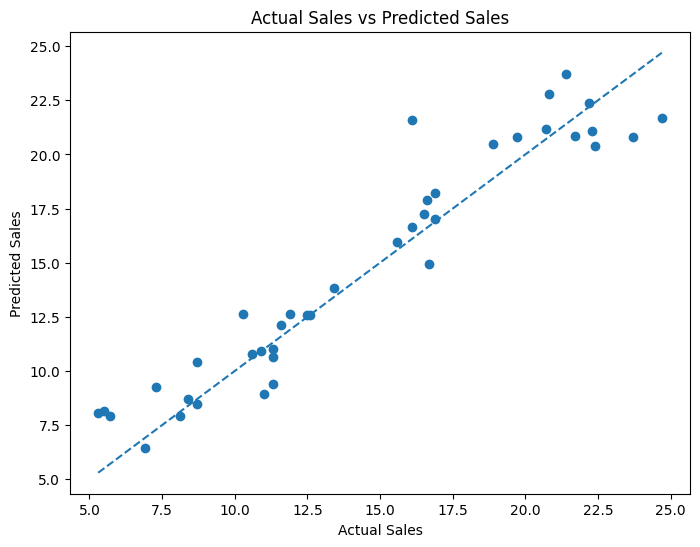

In [11]:
# Create a scatter plot of actual vs predicted sales
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Add a reference line for perfect predictions
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

# Add labels and title
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual Sales vs Predicted Sales")

# Display the plot
plt.show()

Step 14 — Business Recommendation

## 7. Business Recommendation

Radio advertising has the strongest estimated coefficient in the model.
Therefore, the company can consider prioritizing Radio advertising
while monitoring its actual ROI and campaign performance.

The company should not rely only on the coefficient; budget decisions
should also consider advertising cost, reach, and profitability.

Step 15 — Technical Improvement

## 8. Technical Improvement

The current model uses Linear Regression. Prediction accuracy can be
improved by testing other algorithms and using cross-validation.

Possible models include Random Forest, Gradient Boosting, or other
non-linear models.